# 버추얼 아이돌 여론 분석

YouTube 댓글 토큰화 데이터 기반 TF-IDF & N-gram 연관도 분석

## 1. 라이브러리 및 설정

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from itertools import combinations
import ast
import platform
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

# 한글 폰트 설정
if platform.system() == 'Windows':
    FONT_FAMILY = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    FONT_FAMILY = 'AppleGothic'
else:
    FONT_FAMILY = 'NanumGothic'

plt.rcParams['font.family'] = FONT_FAMILY
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.labelcolor'] = '#333333'
plt.rcParams['xtick.color'] = '#333333'
plt.rcParams['ytick.color'] = '#333333'
plt.rcParams['text.color'] = '#333333'

# 색상 팔레트 (최소한의 색상)
COLORS = {
    'primary': '#2C3E50',      # 진한 네이비
    'secondary': '#7F8C8D',    # 그레이
    'accent': '#3498DB',       # 블루
    'light': '#BDC3C7',        # 라이트 그레이
    'dark': '#1A252F'          # 다크
}

print("설정 완료")

설정 완료


## 2. 데이터 로드

In [52]:
# CSV 파일 로드
df = pd.read_csv("./data/Youtube_comment_01/raw/subsets/youtube_comments_N_A.csv")

# 토큰 리스트로 변환
def parse_keywords(val):
    if pd.isna(val):
        return []
    try:
        return ast.literal_eval(val)
    except:
        return []

tokenized_comments = df['keywords'].apply(parse_keywords).tolist()
tokenized_comments = [t for t in tokenized_comments if len(t) > 0]
documents = [' '.join(tokens) for tokens in tokenized_comments]

# 전체 단어 빈도
all_words = [w for tokens in tokenized_comments for w in tokens]
word_freq = Counter(all_words)

print(f"유효 댓글: {len(tokenized_comments):,}개")
print(f"총 단어: {len(all_words):,}개")
print(f"고유 단어: {len(word_freq):,}개")

유효 댓글: 4,777개
총 단어: 30,301개
고유 단어: 5,219개


## 3. TF-IDF 분석

In [53]:
# TF-IDF 계산
tfidf = TfidfVectorizer(max_features=500, min_df=1, max_df=0.95)
tfidf_matrix = tfidf.fit_transform(documents)

# 평균 TF-IDF 점수
feature_names = tfidf.get_feature_names_out()
tfidf_scores = np.array(tfidf_matrix.mean(axis=0)).flatten()

df_tfidf = pd.DataFrame({
    '단어': feature_names,
    'TF-IDF': tfidf_scores
}).sort_values('TF-IDF', ascending=False).reset_index(drop=True)

print("TF-IDF 상위 15개 단어")
df_tfidf.head(15)

TF-IDF 상위 15개 단어


,단어,TF-IDF
0,있다,0.039388
1,아니다,0.037979
2,좋다,0.028230
3,진짜,0.027990
4,사람,0.027505
5,좋아하다,0.023766
6,없다,0.023554
7,같다,0.022714
8,그렇다,0.021932
9,노래,0.021465


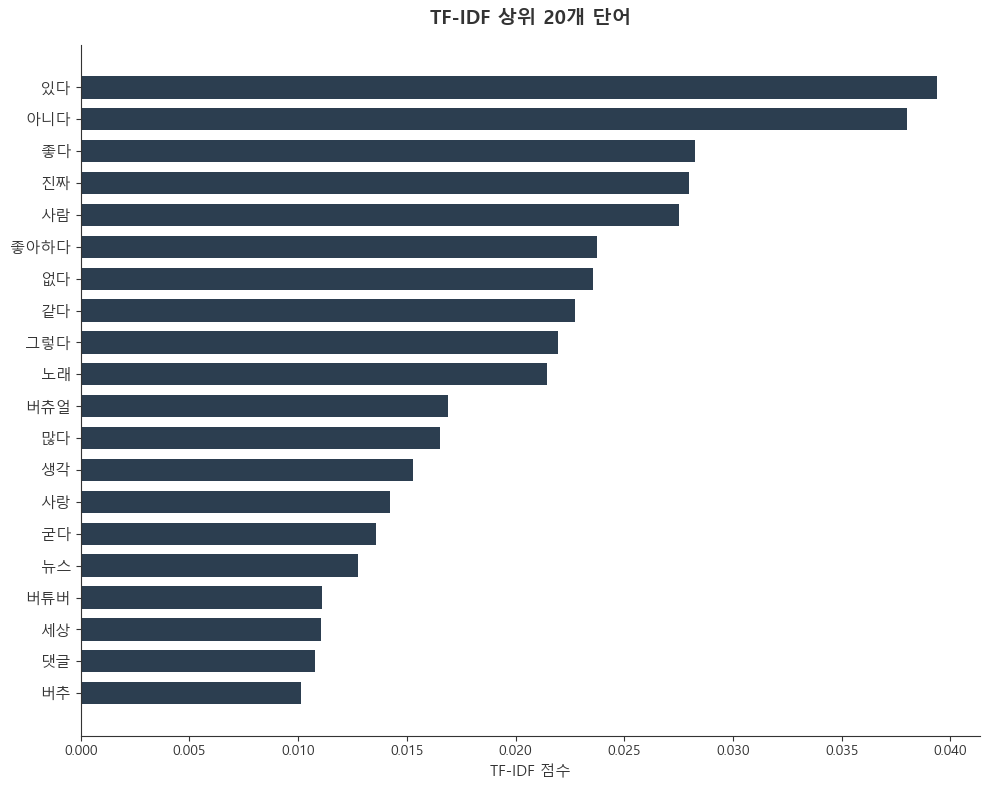

In [54]:
# TF-IDF 시각화
fig, ax = plt.subplots(figsize=(10, 8))

top20 = df_tfidf.head(20)
y_pos = range(len(top20))

ax.barh(y_pos, top20['TF-IDF'].values[::-1], color=COLORS['primary'], height=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(top20['단어'].values[::-1], fontsize=11)
ax.set_xlabel('TF-IDF 점수', fontsize=11)
ax.set_title('TF-IDF 상위 20개 단어', fontsize=14, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('01_tfidf_top20.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 4. N-gram 분석

In [55]:
# N-gram 추출 함수
def extract_ngrams(docs, n):
    ngrams = []
    for tokens in docs:
        if len(tokens) >= n:
            for i in range(len(tokens) - n + 1):
                ngrams.append(tuple(tokens[i:i+n]))
    return Counter(ngrams)

bigram_freq = extract_ngrams(tokenized_comments, 2)
trigram_freq = extract_ngrams(tokenized_comments, 3)

# DataFrame 생성
df_bigram = pd.DataFrame([
    {'Bigram': ' → '.join(g), '빈도': c} 
    for g, c in bigram_freq.most_common(30)
])

df_trigram = pd.DataFrame([
    {'Trigram': ' → '.join(g), '빈도': c} 
    for g, c in trigram_freq.most_common(30)
])

print(f"Bigram 패턴: {len(bigram_freq):,}개")
print(f"Trigram 패턴: {len(trigram_freq):,}개")

Bigram 패턴: 20,842개
Trigram 패턴: 21,150개


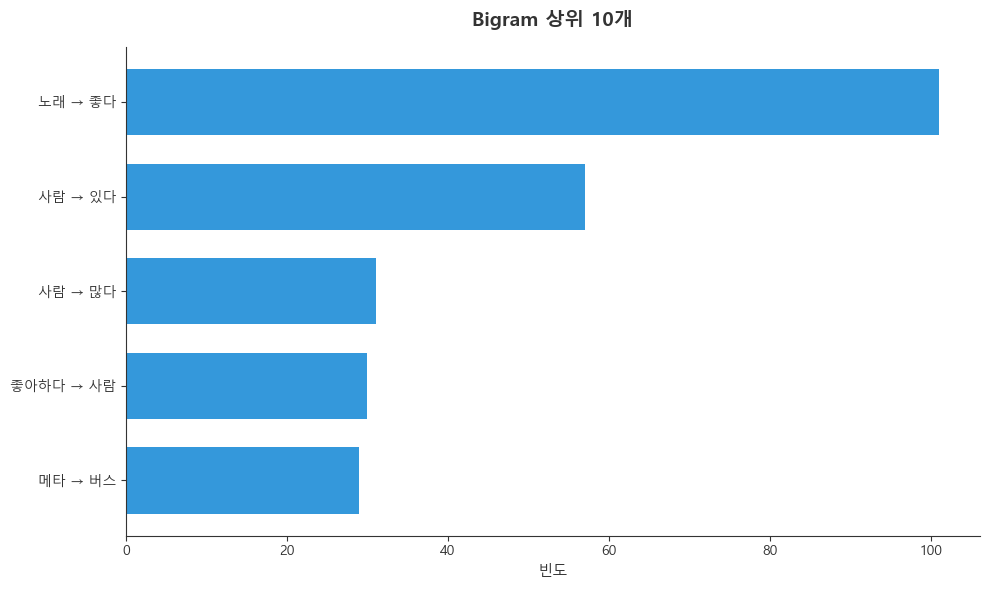

In [56]:
# Bigram 시각화
fig, ax = plt.subplots(figsize=(10, 6))

top15_bi = df_bigram.head(5)
y_pos = range(len(top15_bi))

ax.barh(y_pos, top15_bi['빈도'].values[::-1], color=COLORS['accent'], height=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(top15_bi['Bigram'].values[::-1], fontsize=10)
ax.set_xlabel('빈도', fontsize=11)
ax.set_title('Bigram 상위 10개', fontsize=14, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('02_bigram_top15.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

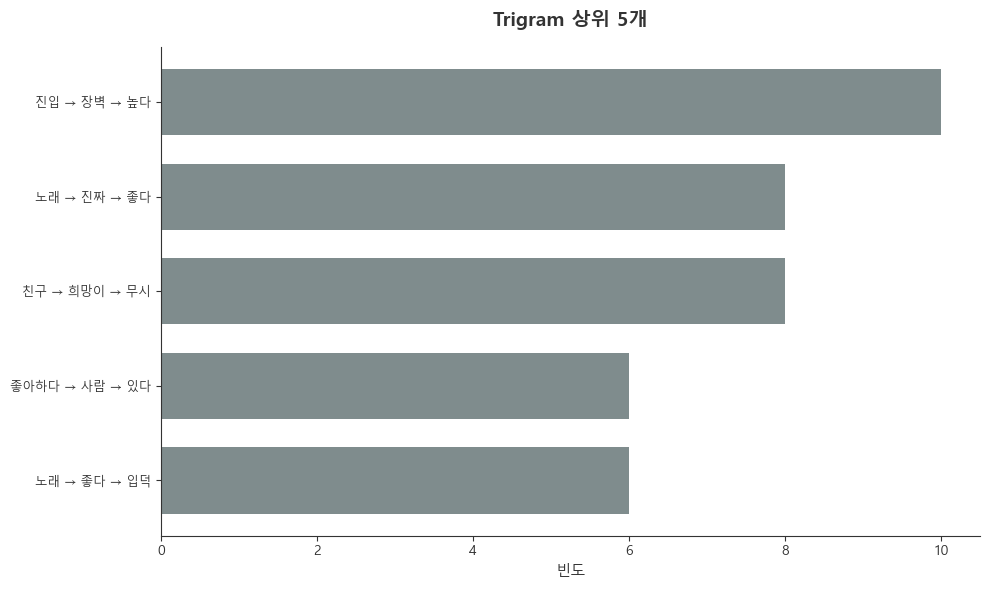

In [57]:
# Trigram 시각화
fig, ax = plt.subplots(figsize=(10, 6))

top15_tri = df_trigram.head(5)
y_pos = range(len(top15_tri))

ax.barh(y_pos, top15_tri['빈도'].values[::-1], color=COLORS['secondary'], height=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(top15_tri['Trigram'].values[::-1], fontsize=9)
ax.set_xlabel('빈도', fontsize=11)
ax.set_title('Trigram 상위 5개', fontsize=14, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('03_trigram_top15.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 5. 동시출현 분석

In [58]:
# 동시출현 계산
min_freq = 5
vocab = {w for w, c in word_freq.items() if c >= min_freq}

cooccurrence = defaultdict(int)
for tokens in tokenized_comments:
    filtered = [t for t in set(tokens) if t in vocab]
    for w1, w2 in combinations(filtered, 2):
        pair = tuple(sorted([w1, w2]))
        cooccurrence[pair] += 1

df_cooc = pd.DataFrame([
    {'단어1': p[0], '단어2': p[1], '동시출현': c}
    for p, c in cooccurrence.items()
]).sort_values('동시출현', ascending=False).reset_index(drop=True)

print(f"동시출현 단어쌍: {len(df_cooc):,}개")
df_cooc.head(15)

동시출현 단어쌍: 65,654개


,단어1,단어2,동시출현
0,사람,있다,163
1,노래,좋다,135
2,아니다,있다,129
3,없다,있다,111
4,사람,아니다,111
5,생각,있다,105
6,사람,좋아하다,101
7,같다,있다,101
8,있다,좋아하다,100
9,있다,좋다,98


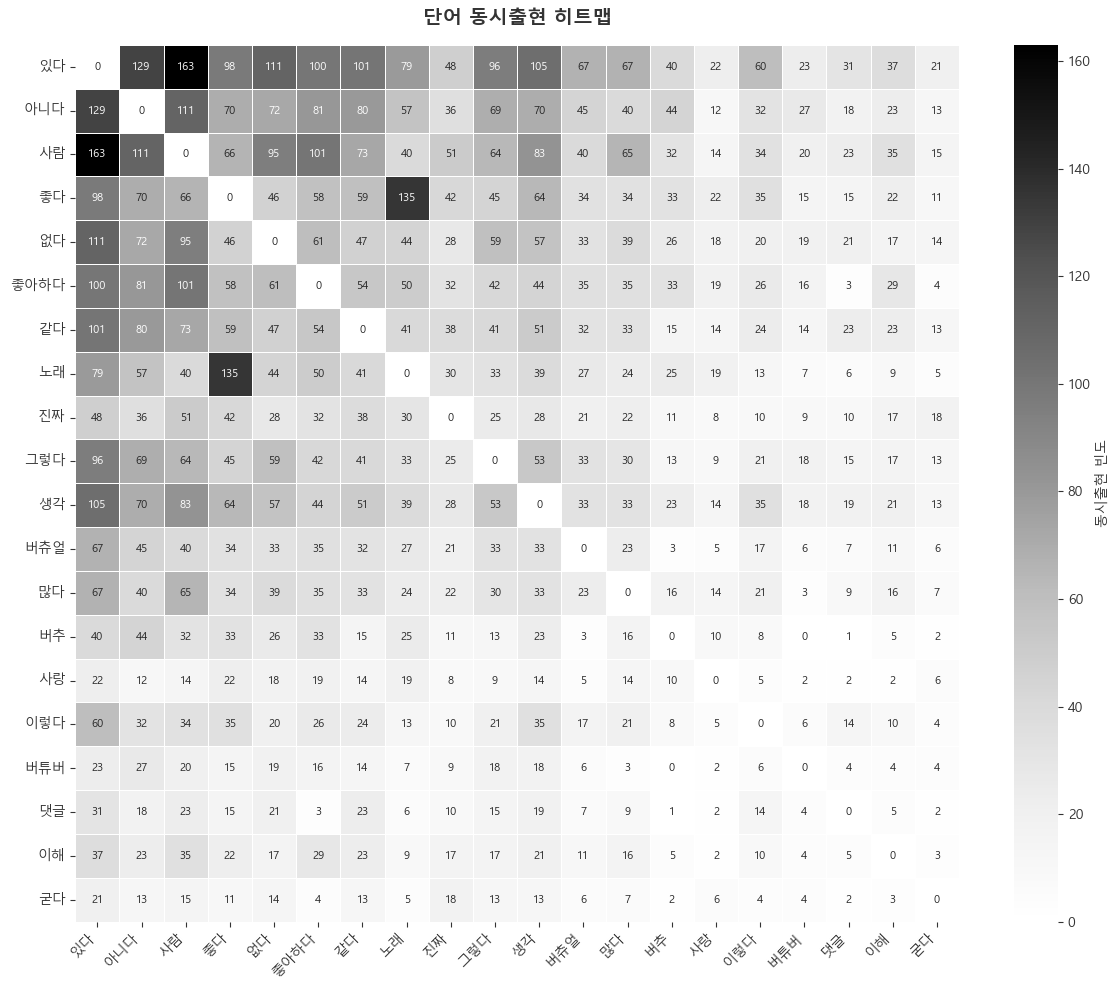

In [59]:
# 동시출현 히트맵
top_words = [w for w, _ in word_freq.most_common(20)]
n = len(top_words)
matrix = np.zeros((n, n))

for (w1, w2), c in cooccurrence.items():
    if w1 in top_words and w2 in top_words:
        i, j = top_words.index(w1), top_words.index(w2)
        matrix[i][j] = c
        matrix[j][i] = c

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(matrix, 
            xticklabels=top_words, 
            yticklabels=top_words,
            cmap='Greys',
            annot=True, 
            fmt='.0f',
            annot_kws={'size': 8},
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': '동시출현 빈도'},
            ax=ax)

ax.set_title('단어 동시출현 히트맵', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('04_cooccurrence_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 6. PMI 연관도 분석

In [60]:
# PMI 계산
total_words = sum(word_freq.values())
n_docs = len(tokenized_comments)

pmi_list = []
for (w1, w2), cooc in cooccurrence.items():
    if word_freq[w1] >= 5 and word_freq[w2] >= 5 and cooc >= 3:
        p_w1_w2 = cooc / n_docs
        p_w1 = word_freq[w1] / total_words
        p_w2 = word_freq[w2] / total_words
        
        if p_w1 * p_w2 > 0:
            pmi = np.log2(p_w1_w2 / (p_w1 * p_w2))
            pmi_list.append({
                '단어1': w1, '단어2': w2,
                'PMI': pmi, '동시출현': cooc
            })

df_pmi = pd.DataFrame(pmi_list).sort_values('PMI', ascending=False).reset_index(drop=True)

print(f"PMI 분석 단어쌍: {len(df_pmi):,}개")
df_pmi.head(15)

PMI 분석 단어쌍: 8,536개


,단어1,단어2,PMI,동시출현
0,물품,보관,14.744911,7
1,여신,천재,14.493373,3
2,도축업,바오,14.382341,6
3,여신,홍조,14.230338,3
4,천재,홍조,14.230338,3
5,엑소,초능력,14.066840,5
6,비챤,천재,14.007946,3
7,비챤,여신,14.007946,3
8,목록,재생,13.967304,5
9,버들,버튜,13.967304,4


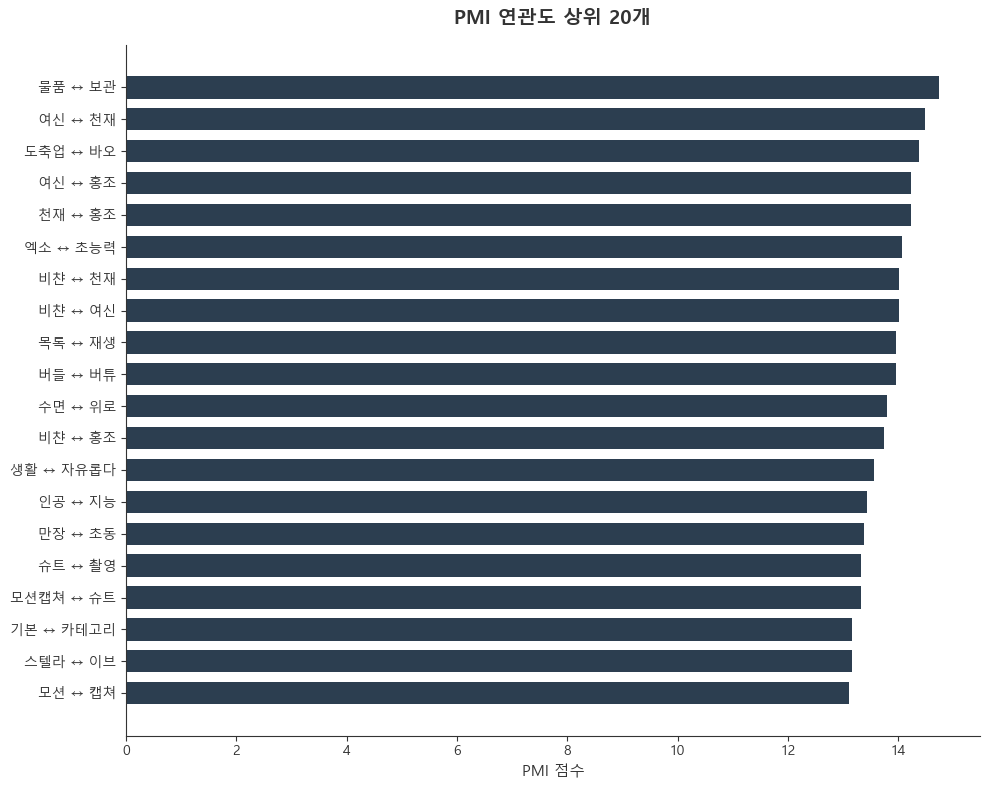

In [61]:
# PMI 시각화
fig, ax = plt.subplots(figsize=(10, 8))

top20_pmi = df_pmi.head(20).copy()
top20_pmi['쌍'] = top20_pmi['단어1'] + ' ↔ ' + top20_pmi['단어2']
y_pos = range(len(top20_pmi))

ax.barh(y_pos, top20_pmi['PMI'].values[::-1], color=COLORS['primary'], height=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(top20_pmi['쌍'].values[::-1], fontsize=10)
ax.set_xlabel('PMI 점수', fontsize=11)
ax.set_title('PMI 연관도 상위 20개', fontsize=14, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('05_pmi_top20.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 7. 네트워크 그래프

In [62]:
# 동시출현 기반 네트워크
G = nx.Graph()

for _, row in df_cooc.head(60).iterrows():
    G.add_edge(row['단어1'], row['단어2'], weight=row['동시출현'])

print(f"노드: {G.number_of_nodes()}, 엣지: {G.number_of_edges()}")

노드: 19, 엣지: 60


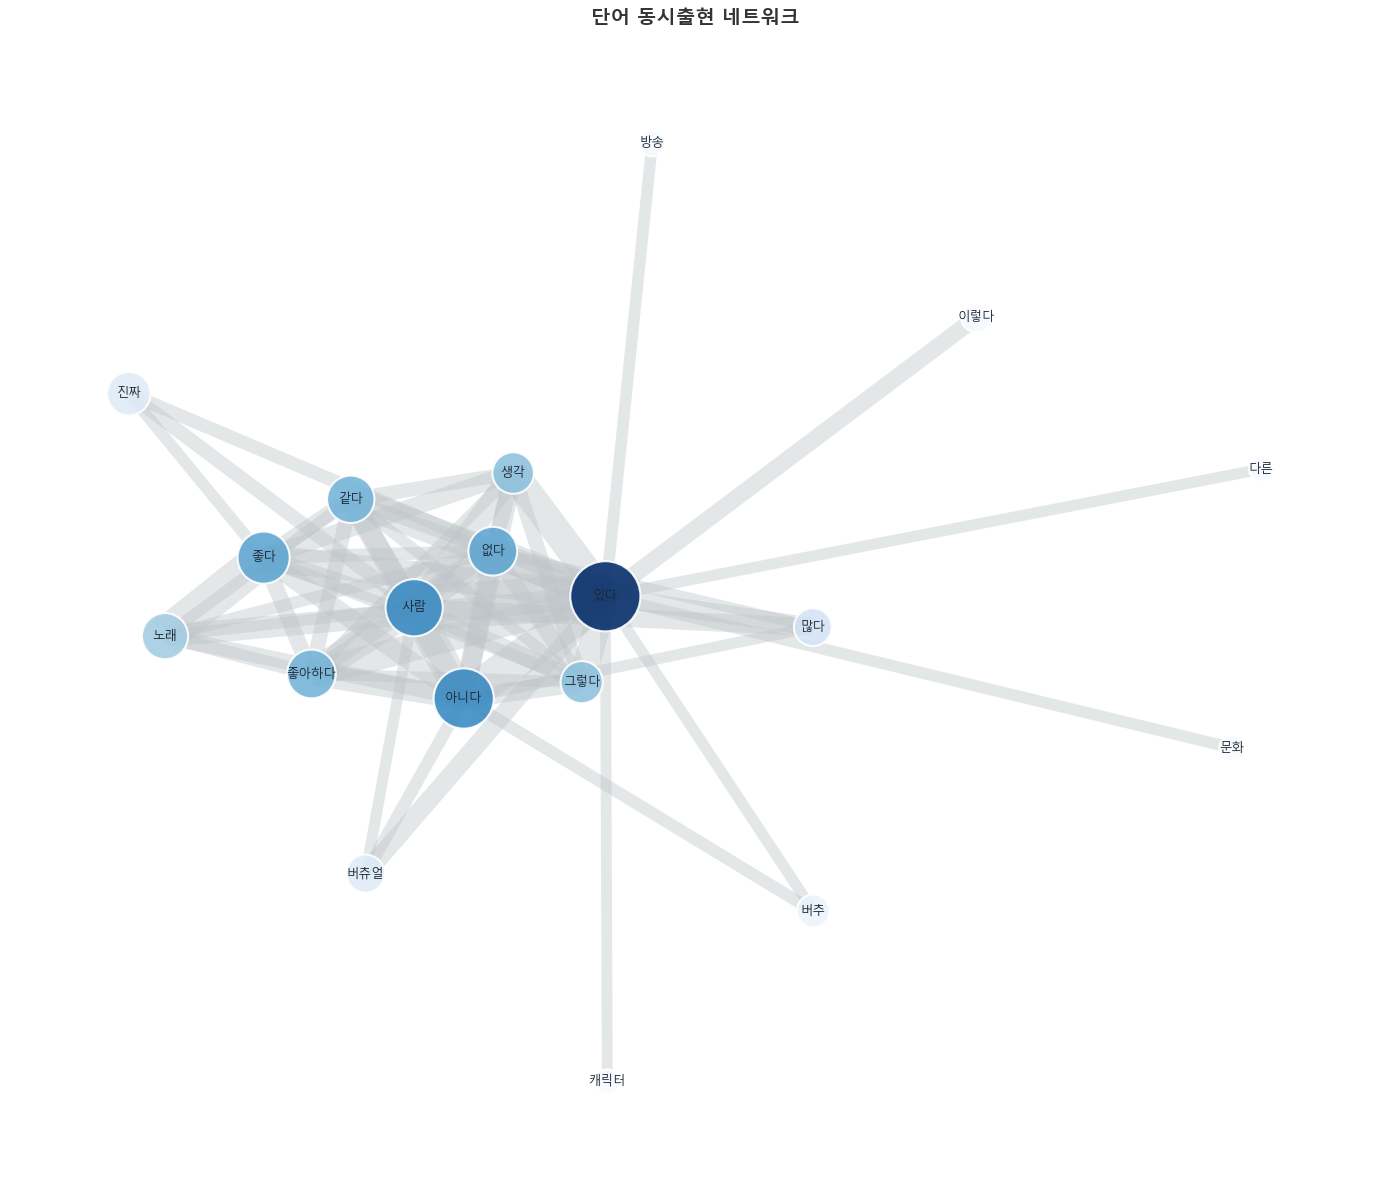

In [63]:
# 네트워크 시각화
fig, ax = plt.subplots(figsize=(14, 12))

pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# 노드 크기 (빈도 기반)
node_sizes = [word_freq.get(n, 10) * 3 for n in G.nodes()]

# 엣지 두께
edge_weights = [G[u][v]['weight'] * 0.2 for u, v in G.edges()]

# 노드 색상 (연결 정도)
degrees = dict(G.degree())
node_colors = [degrees[n] for n in G.nodes()]

# 그리기
nx.draw_networkx_edges(G, pos, width=edge_weights, alpha=0.4, 
                       edge_color=COLORS['light'], ax=ax)

nodes = nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                               node_color=node_colors, cmap=plt.cm.Blues,
                               alpha=0.9, edgecolors='white', linewidths=1.5, ax=ax)

nx.draw_networkx_labels(G, pos, font_size=9, font_color=COLORS['dark'],
                        font_family=FONT_FAMILY, ax=ax)

ax.set_title('단어 동시출현 네트워크', fontsize=14, fontweight='bold', pad=15)
ax.axis('off')

plt.tight_layout()
plt.savefig('06_cooc_network.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

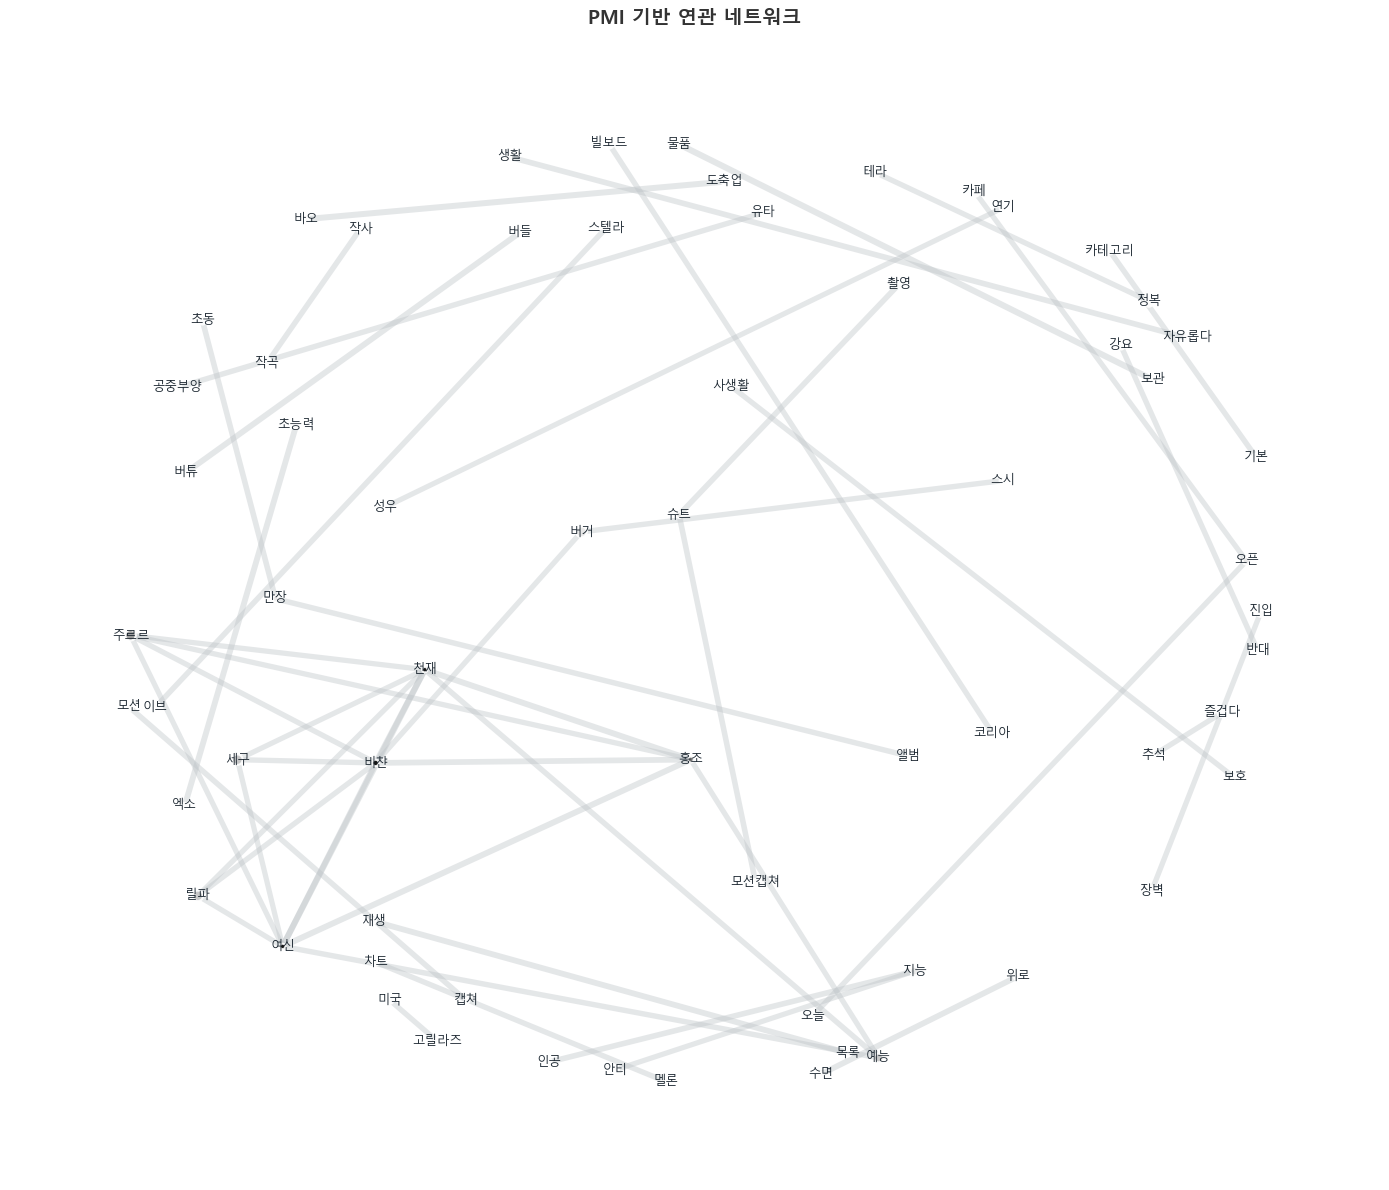

In [64]:
# PMI 기반 네트워크
G_pmi = nx.Graph()

pmi_edges = df_pmi[(df_pmi['PMI'] > 0) & (df_pmi['동시출현'] >= 3)].head(50)
for _, row in pmi_edges.iterrows():
    G_pmi.add_edge(row['단어1'], row['단어2'], weight=row['PMI'])

fig, ax = plt.subplots(figsize=(14, 12))

pos_pmi = nx.spring_layout(G_pmi, k=2.5, iterations=50, seed=42)

node_sizes_pmi = [word_freq.get(n, 10) * 3 for n in G_pmi.nodes()]
edge_weights_pmi = [max(G_pmi[u][v]['weight'] * 0.3, 0.5) for u, v in G_pmi.edges()]
degrees_pmi = dict(G_pmi.degree())
node_colors_pmi = [degrees_pmi[n] for n in G_pmi.nodes()]

nx.draw_networkx_edges(G_pmi, pos_pmi, width=edge_weights_pmi, alpha=0.4,
                       edge_color=COLORS['light'], ax=ax)

nx.draw_networkx_nodes(G_pmi, pos_pmi, node_size=node_sizes_pmi,
                       node_color=node_colors_pmi, cmap=plt.cm.Greys,
                       alpha=0.9, edgecolors='white', linewidths=1.5, ax=ax)

nx.draw_networkx_labels(G_pmi, pos_pmi, font_size=9, font_color=COLORS['dark'],
                        font_family=FONT_FAMILY, ax=ax)

ax.set_title('PMI 기반 연관 네트워크', fontsize=14, fontweight='bold', pad=15)
ax.axis('off')

plt.tight_layout()
plt.savefig('07_pmi_network.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

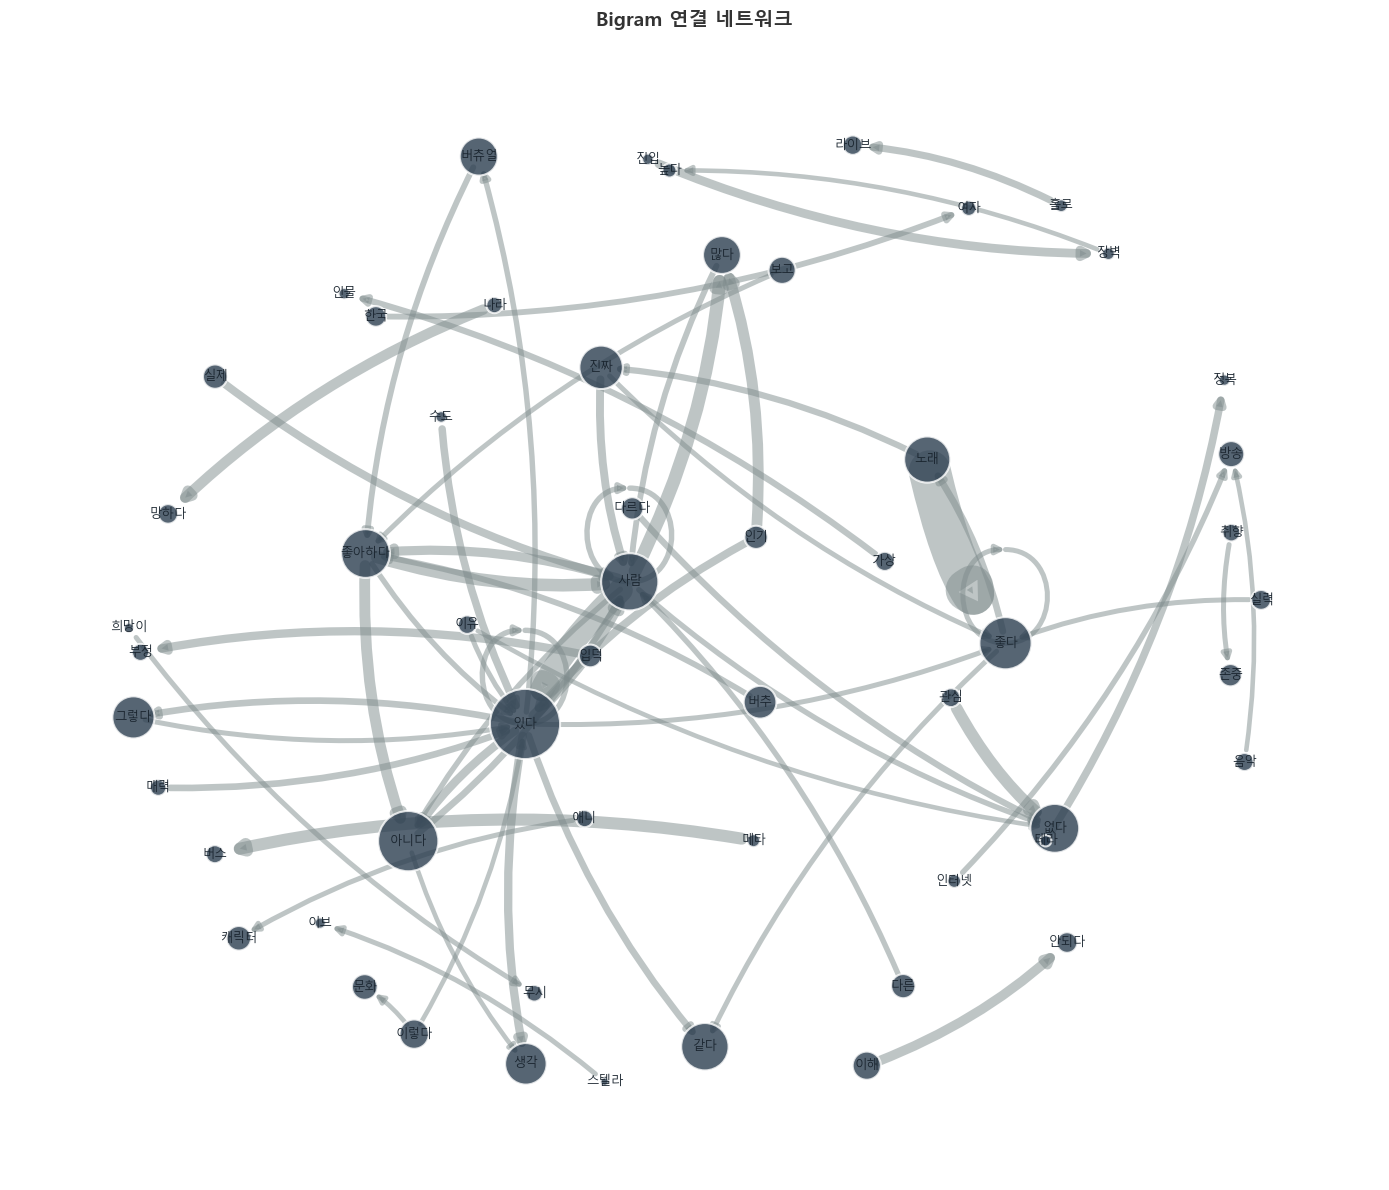

In [65]:
# Bigram 방향 네트워크
G_bi = nx.DiGraph()

for gram, count in bigram_freq.most_common(60):
    if count >= 2:
        G_bi.add_edge(gram[0], gram[1], weight=count)

fig, ax = plt.subplots(figsize=(14, 12))

pos_bi = nx.spring_layout(G_bi, k=2, iterations=50, seed=42)

node_sizes_bi = [word_freq.get(n, 10) * 3 for n in G_bi.nodes()]
edge_weights_bi = [G_bi[u][v]['weight'] * 0.3 for u, v in G_bi.edges()]

nx.draw_networkx_edges(G_bi, pos_bi, width=edge_weights_bi, alpha=0.5,
                       edge_color=COLORS['secondary'], arrows=True,
                       arrowsize=12, connectionstyle="arc3,rad=0.1", ax=ax)

nx.draw_networkx_nodes(G_bi, pos_bi, node_size=node_sizes_bi,
                       node_color=COLORS['primary'], alpha=0.8,
                       edgecolors='white', linewidths=1.5, ax=ax)

nx.draw_networkx_labels(G_bi, pos_bi, font_size=9, font_color=COLORS['dark'],
                        font_family=FONT_FAMILY, ax=ax)

ax.set_title('Bigram 연결 네트워크', fontsize=14, fontweight='bold', pad=15)
ax.axis('off')

plt.tight_layout()
plt.savefig('08_bigram_network.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 8. 종합 대시보드

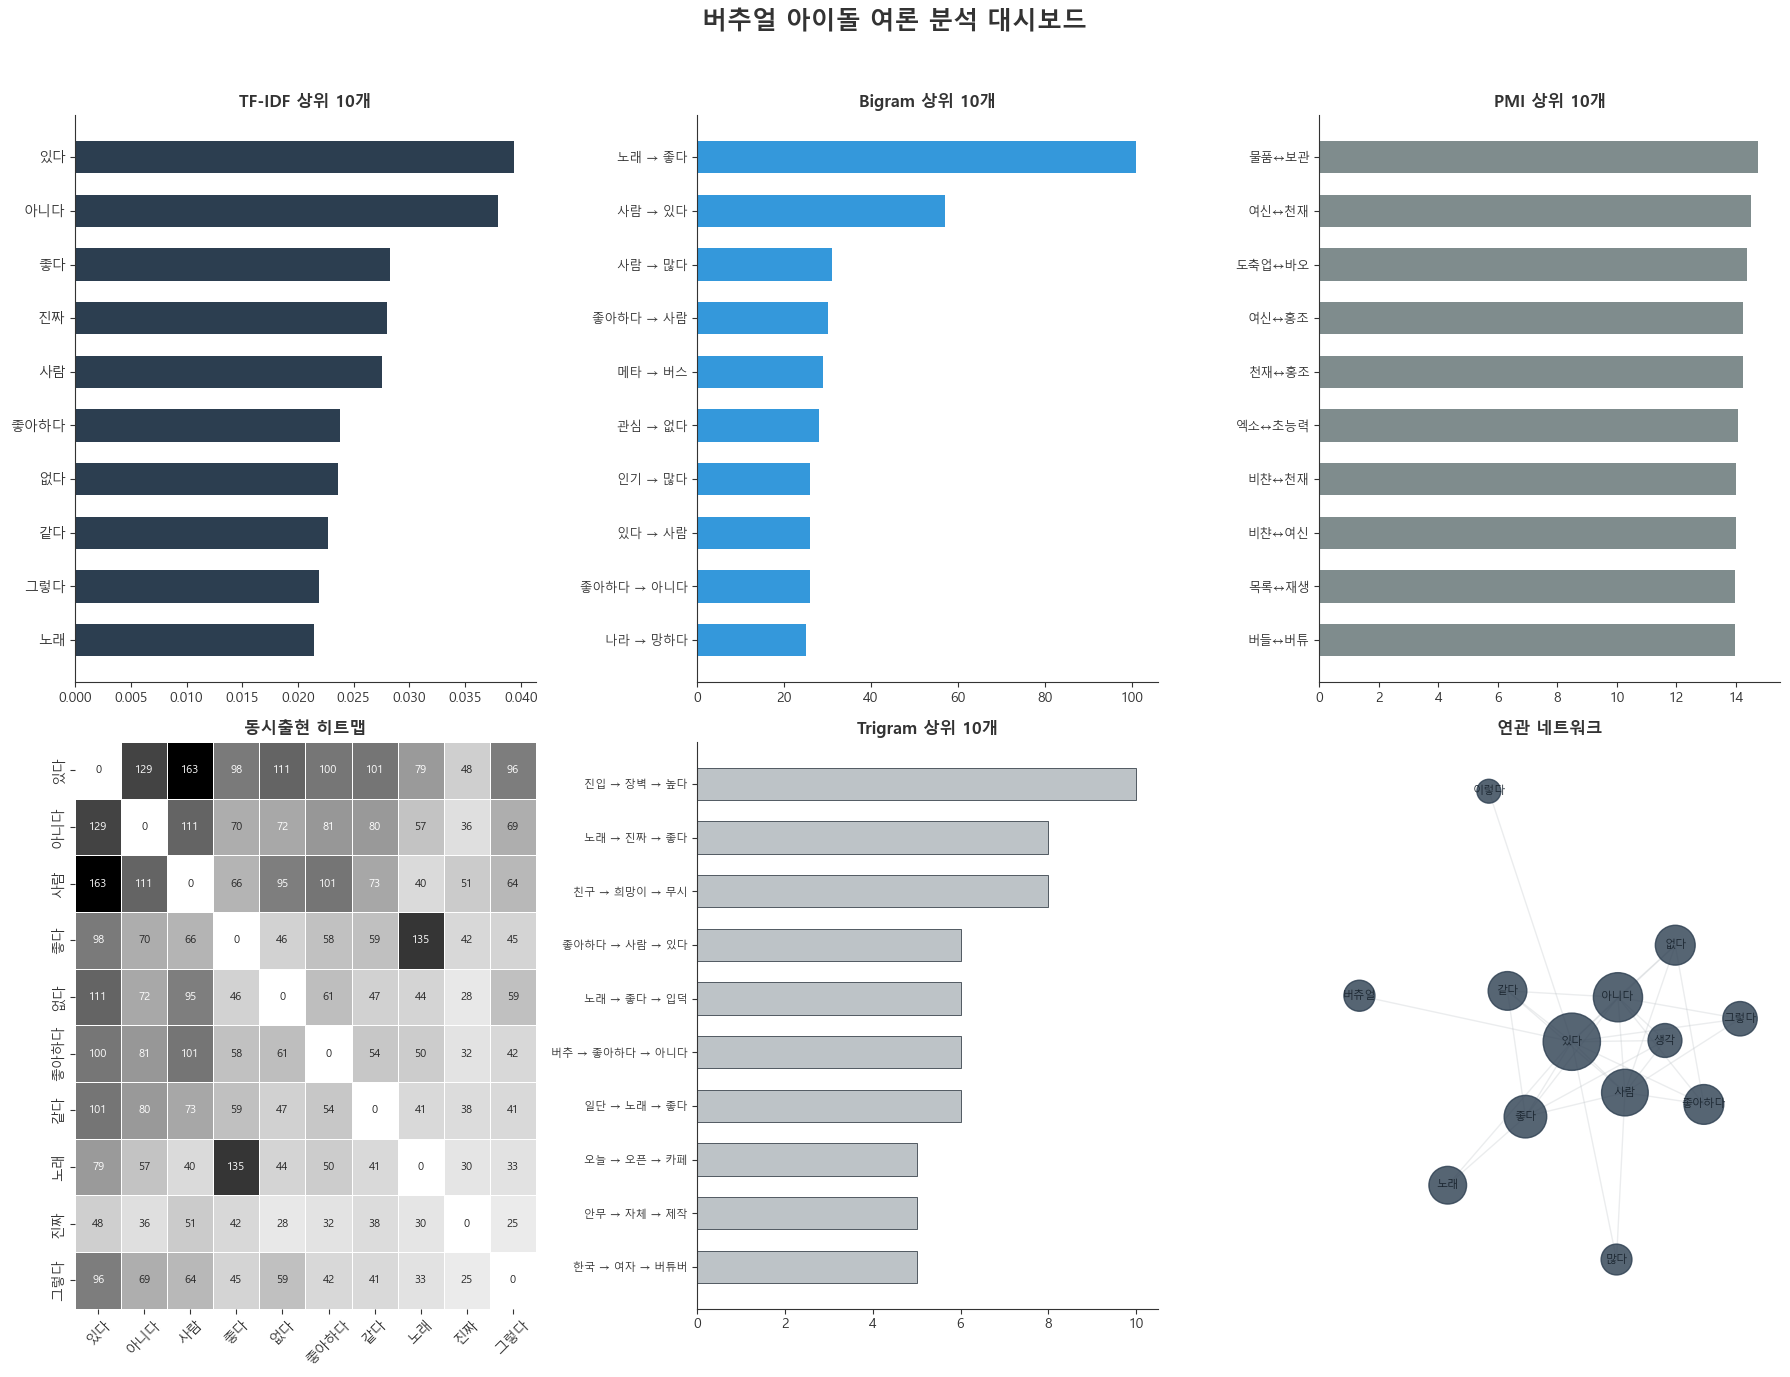

In [66]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('버추얼 아이돌 여론 분석 대시보드', fontsize=18, fontweight='bold', y=0.98)

# 1. TF-IDF
ax1 = fig.add_subplot(2, 3, 1)
top10 = df_tfidf.head(10)
ax1.barh(range(10), top10['TF-IDF'].values[::-1], color=COLORS['primary'], height=0.6)
ax1.set_yticks(range(10))
ax1.set_yticklabels(top10['단어'].values[::-1], fontsize=10)
ax1.set_title('TF-IDF 상위 10개', fontsize=12, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 2. Bigram
ax2 = fig.add_subplot(2, 3, 2)
top10_bi = df_bigram.head(10)
ax2.barh(range(10), top10_bi['빈도'].values[::-1], color=COLORS['accent'], height=0.6)
ax2.set_yticks(range(10))
ax2.set_yticklabels(top10_bi['Bigram'].values[::-1], fontsize=9)
ax2.set_title('Bigram 상위 10개', fontsize=12, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 3. PMI
ax3 = fig.add_subplot(2, 3, 3)
top10_pmi = df_pmi.head(10).copy()
top10_pmi['쌍'] = top10_pmi['단어1'] + '↔' + top10_pmi['단어2']
ax3.barh(range(10), top10_pmi['PMI'].values[::-1], color=COLORS['secondary'], height=0.6)
ax3.set_yticks(range(10))
ax3.set_yticklabels(top10_pmi['쌍'].values[::-1], fontsize=9)
ax3.set_title('PMI 상위 10개', fontsize=12, fontweight='bold')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# 4. 히트맵
ax4 = fig.add_subplot(2, 3, 4)
top10_words = [w for w, _ in word_freq.most_common(10)]
small_matrix = np.zeros((10, 10))
for (w1, w2), c in cooccurrence.items():
    if w1 in top10_words and w2 in top10_words:
        i, j = top10_words.index(w1), top10_words.index(w2)
        small_matrix[i][j] = c
        small_matrix[j][i] = c
sns.heatmap(small_matrix, xticklabels=top10_words, yticklabels=top10_words,
            cmap='Greys', annot=True, fmt='.0f', ax=ax4, annot_kws={'size': 8},
            cbar=False, linewidths=0.5)
ax4.set_title('동시출현 히트맵', fontsize=12, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)

# 5. Trigram
ax5 = fig.add_subplot(2, 3, 5)
top10_tri = df_trigram.head(10)
ax5.barh(range(10), top10_tri['빈도'].values[::-1], color=COLORS['light'], height=0.6,
         edgecolor=COLORS['dark'], linewidth=0.5)
ax5.set_yticks(range(10))
ax5.set_yticklabels(top10_tri['Trigram'].values[::-1], fontsize=8)
ax5.set_title('Trigram 상위 10개', fontsize=12, fontweight='bold')
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

# 6. 네트워크 (간소화)
ax6 = fig.add_subplot(2, 3, 6)
G_small = nx.Graph()
for _, row in df_cooc.head(30).iterrows():
    G_small.add_edge(row['단어1'], row['단어2'], weight=row['동시출현'])
pos_s = nx.spring_layout(G_small, k=2, seed=42)
sizes_s = [word_freq.get(n, 10) * 2 for n in G_small.nodes()]
nx.draw_networkx_edges(G_small, pos_s, alpha=0.3, edge_color=COLORS['light'], ax=ax6)
nx.draw_networkx_nodes(G_small, pos_s, node_size=sizes_s, node_color=COLORS['primary'],
                       alpha=0.8, ax=ax6)
nx.draw_networkx_labels(G_small, pos_s, font_size=8, font_color=COLORS['dark'],
                        font_family=FONT_FAMILY, ax=ax6)
ax6.set_title('연관 네트워크', fontsize=12, fontweight='bold')
ax6.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('09_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 9. 분석 요약

In [ ]:
print("="*60)
print("버추얼 아이돌 여론 분석 결과")
print("="*60)

print(f"\n[기본 통계]")
print(f"  분석 댓글: {len(tokenized_comments):,}개")
print(f"  총 단어: {len(all_words):,}개")
print(f"  고유 단어: {len(word_freq):,}개")

print(f"\n[TF-IDF 상위 10개]")
for i, row in df_tfidf.head(10).iterrows():
    print(f"  {i+1}. {row['단어']} ({row['TF-IDF']:.4f})")

print(f"\n[주요 Bigram]")
for i, row in df_bigram.head(10).iterrows():
    print(f"  {i+1}. {row['Bigram']} ({row['빈도']}회)")

print(f"\n[PMI 연관 단어쌍]")
for i, row in df_pmi.head(10).iterrows():
    print(f"  {i+1}. {row['단어1']} ↔ {row['단어2']} (PMI: {row['PMI']:.2f})")

print("\n" + "="*60)

---
### 저장된 파일
- `01_tfidf_top20.png`
- `02_bigram_top15.png`
- `03_trigram_top15.png`
- `04_cooccurrence_heatmap.png`
- `05_pmi_top20.png`
- `06_cooc_network.png`
- `07_pmi_network.png`
- `08_bigram_network.png`
- `09_dashboard.png`